# HW13 – Токенизация текста, инференс BERT и базовый fine-tuning для классификации

В этом ноутбуке:
1. Загружаем датасет `emotion` (6 классов эмоций).
2. Проводим sanity-check данных.
3. Разбираем токенизацию на нескольких примерах.
4. Запускаем инференс готовой pretrained модели.
5. Выполняем fine-tuning BERT-подобной модели.
6. Оцениваем качество на test: accuracy, f1_macro, confusion matrix.
7. Анализируем ошибки модели.

## 1. Импорты, seed и среда

In [1]:
import random
import os
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from datasets import load_dataset, DatasetDict
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

ARTIFACTS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("Artifacts dir:", ARTIFACTS_DIR)

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifacts dir: c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\ai-student-maxim-main\homeworks\HW13\artifacts


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Torch: {torch.__version__}")

Device: cpu


## 2. Данные и первичный анализ

Используем датасет **`dair-ai/emotion`** – 6 эмоций: `sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.  
Датасет уже содержит split на `train`, `validation`, `test`.

In [3]:
raw_dataset = load_dataset("dair-ai/emotion")
print(raw_dataset)
print()

label_names = raw_dataset["train"].features["label"].names
num_labels = len(label_names)

label2id = {name: idx for idx, name in enumerate(label_names)}
id2label = {idx: name for idx, name in enumerate(label_names)}

print("Классы:", label_names)
print("Число классов:", num_labels)
print("label2id:", label2id)
print()

for split_name in ["train", "validation", "test"]:
    print(f"{split_name}: {len(raw_dataset[split_name])} примеров")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Число классов: 6
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров


In [4]:
# Несколько примеров текстов и меток
train_df = raw_dataset["train"].to_pandas()
train_df["label_name"] = train_df["label"].map(id2label)

print("Первые 5 примеров:")
display(train_df[["text", "label_name"]].head(5))

print("\nРаспределение классов в train:")
display(train_df["label_name"].value_counts())

print("\nСредняя длина текста (в символах):", train_df["text"].str.len().mean().round(1))
print("Медианная длина текста (в символах):", train_df["text"].str.len().median())

Первые 5 примеров:


,text,label_name
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger



Распределение классов в train:


label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


Средняя длина текста (в символах): 96.8
Медианная длина текста (в символах): 86.0


## 3. Токенизация

Используем модель **`distilbert-base-uncased`** — компактный англоязычный BERT.  
Покажем, как текст превращается во вход модели: токены, `input_ids`, `attention_mask`, special tokens.

In [5]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocab size:", tokenizer.vocab_size)
print("Model max length:", tokenizer.model_max_length)
print("Special tokens:", {
    "CLS": tokenizer.cls_token,
    "SEP": tokenizer.sep_token,
    "PAD": tokenizer.pad_token,
    "UNK": tokenizer.unk_token,
    "MASK": tokenizer.mask_token,
})

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Maxim\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Tokenizer: BertTokenizer
Vocab size: 30522
Model max length: 512
Special tokens: {'CLS': '[CLS]', 'SEP': '[SEP]', 'PAD': '[PAD]', 'UNK': '[UNK]', 'MASK': '[MASK]'}


In [6]:
# Разбор токенизации на 5 примерах из датасета
sample_texts = [
    raw_dataset["train"][i]["text"] for i in [0, 1, 2, 100, 200]
]

for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
    )
    print(f"Text: {text}")
    print(f"Tokens ({len(tokens)}): {tokens[:20]}{'...' if len(tokens) > 20 else ''}")
    print(f"input_ids[:15]: {encoded['input_ids'][:15]}")
    print(f"attention_mask[:15]: {encoded['attention_mask'][:15]}")
    print(f"Decoded: {tokenizer.decode(encoded['input_ids'])}")
    print()

Text: i didnt feel humiliated
Tokens (5): ['i', 'didn', '##t', 'feel', 'humiliated']
input_ids[:15]: [101, 1045, 2134, 2102, 2514, 26608, 102]
attention_mask[:15]: [1, 1, 1, 1, 1, 1, 1]
Decoded: [CLS] i didnt feel humiliated [SEP]

Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Tokens (21): ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is']...
input_ids[:15]: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108]
attention_mask[:15]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Decoded: [CLS] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake [SEP]

Text: im grabbing a minute to post i feel greedy wrong
Tokens (10): ['im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong']
input_ids[:15]: [10

In [7]:
# Пример padding и truncation на батче
batch_example = tokenizer(
    sample_texts[:3],
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

print("Batch keys:", list(batch_example.keys()))
print("input_ids shape:", tuple(batch_example["input_ids"].shape))
print("attention_mask shape:", tuple(batch_example["attention_mask"].shape))
print()

for i, text in enumerate(sample_texts[:3]):
    ids = batch_example["input_ids"][i].tolist()
    mask = batch_example["attention_mask"][i].tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)
    print(f"--- Example {i} ---")
    print(f"Text: {text[:80]}..." if len(text) > 80 else f"Text: {text}")
    print(f"Tokens: {toks}")
    print(f"Mask:   {mask}")
    print(f"PAD count: {mask.count(0)}, Real tokens: {mask.count(1)}")
    print()

Batch keys: ['input_ids', 'token_type_ids', 'attention_mask']
input_ids shape: (3, 23)
attention_mask shape: (3, 23)

--- Example 0 ---
Text: i didnt feel humiliated
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Mask:   [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
PAD count: 16, Real tokens: 7

--- Example 1 ---
Text: i can go from feeling so hopeless to so damned hopeful just from being around so...
Tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
Mask:   [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
PAD count: 0, Real tokens: 23

--- Example 2 ---
Text: im grabbing a minute to post i feel greedy wrong
Tokens: ['[CLS]', 'im',

## 4. Инференс готовой pretrained модели

Проверим готовую модель **`bhadresh-savani/distilbert-base-uncased-emotion`** (обучена на том же датасете emotion).  
Это модель sentiment/emotion classification – посмотрим, как она работает без нашего дообучения.

In [8]:
PRETRAINED_MODEL = "bhadresh-savani/distilbert-base-uncased-emotion"

pretrained_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
pretrained_model = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_MODEL)
pretrained_model.to(device)
pretrained_model.eval()

print("Pretrained model:", PRETRAINED_MODEL)
print("Labels:", pretrained_model.config.id2label)
print("Num labels:", pretrained_model.config.num_labels)

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Maxim\.cache\huggingface\hub\models--bhadresh-savani--distilbert-base-uncased-emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8961.08i

Pretrained model: bhadresh-savani/distilbert-base-uncased-emotion
Labels: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Num labels: 6


In [9]:
# Инференс на 10 примерах из test
inference_texts = [raw_dataset["test"][i]["text"] for i in range(10)]
inference_true = [raw_dataset["test"][i]["label"] for i in range(10)]

encoded = pretrained_tokenizer(
    inference_texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=128,
)
encoded = {k: v.to(device) for k, v in encoded.items()}

with torch.no_grad():
    outputs = pretrained_model(**encoded)
    probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()

pred_ids = probs.argmax(axis=1)

pretrained_id2label = pretrained_model.config.id2label

inference_df = pd.DataFrame({
    "text": inference_texts,
    "true_label": [id2label[t] for t in inference_true],
    "pred_label": [pretrained_id2label[int(p)] for p in pred_ids],
    "confidence": [float(probs[i, pred_ids[i]]) for i in range(len(pred_ids))],
})

inference_df["correct"] = inference_df["true_label"] == inference_df["pred_label"]
display(inference_df)
print(f"\nAccuracy на 10 примерах: {inference_df['correct'].mean():.2f}")

,text,true_label,pred_label,confidence,correct
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9989,True
1,im updating my blog because i feel shitty,sadness,sadness,0.9990,True
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9990,True
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9988,True
4,i was feeling a little vain when i did this one,sadness,sadness,0.9989,True
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.9964,True
6,i felt anger when at the end of a telephone call,anger,anger,0.9971,True
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitem...,joy,joy,0.9851,True
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9984,True
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as...,anger,anger,0.9981,True



Accuracy на 10 примерах: 1.00


**Вывод по готовой модели:**  
Готовая модель `bhadresh-savani/distilbert-base-uncased-emotion` неплохо справляется, т.к. она уже обучена на этом датасете.  
Однако наша задача — самостоятельно пройти полный pipeline fine-tuning с `bert-base-uncased`.

## 5. Fine-tuning BERT для классификации текста

### 5.1. Токенизация датасета

In [10]:
# Переименуем столбец label -> labels для Trainer
def rename_label(example):
    example["labels"] = example["label"]
    return example

dataset = raw_dataset.map(rename_label)

MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_fn, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text", "label"])

print(tokenized_dataset)
print("\nПример из train:")
print(tokenized_dataset["train"][0])

Map: 100%|██████████| 2000/2000 [00:00<00:00, 45354.37 examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

Пример из train:
{'labels': 0, 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [11]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

### 5.2. Загрузка модели

In [12]:
set_seed(42)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(device)

print("Model:", model.__class__.__name__)
print("Num labels:", model.config.num_labels)
print("id2label:", model.config.id2label)
print(f"Model on: {next(model.parameters()).device}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8971.97it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: DistilBertForSequenceClassification
Num labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Model on: cpu


### 5.3. Метрики и параметры обучения

In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1_macro}

In [14]:
OUTPUT_DIR = "outputs/hw13_bert_finetuning"

common_kwargs = dict(
    output_dir=OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_kwargs,
    )

print("Training args created.")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"LR: {training_args.learning_rate}")
print(f"FP16: {training_args.fp16}")

Training args created.
Epochs: 3
LR: 2e-05
FP16: False


### 5.4. Запуск fine-tuning

In [15]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
print("\nTraining done.")
print(f"Train loss: {train_result.metrics['train_loss']:.4f}")

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.208149,0.192003,0.930000,0.903253
2,0.124571,0.157699,0.932500,0.906242
3,0.084883,0.149087,0.941000,0.916040


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.75it/s]
c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.38it/s]
c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.43it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma']


Training done.
Train loss: 0.2402


### 5.5. История обучения

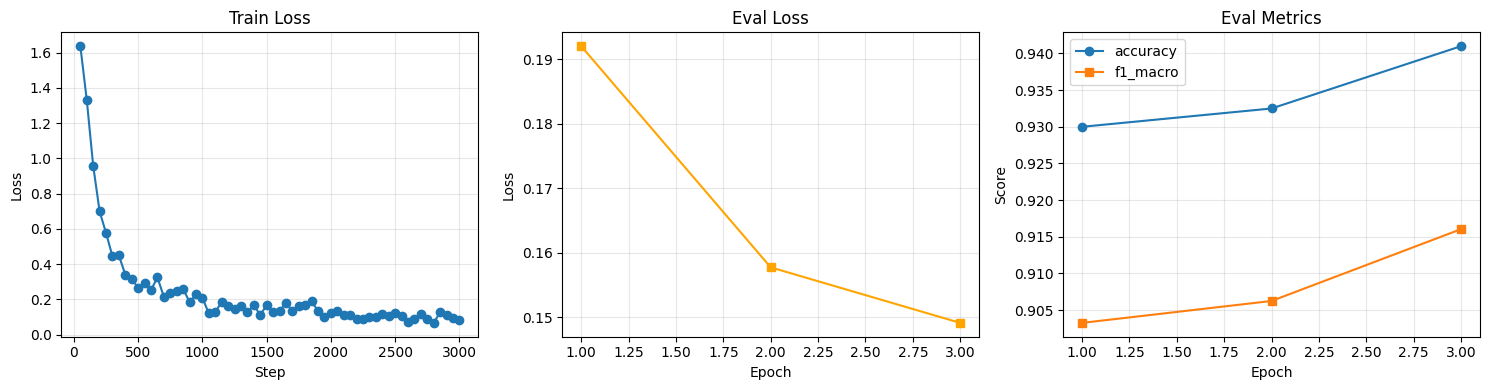

Saved training_curves.png


In [16]:
history_df = pd.DataFrame(trainer.state.log_history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train loss
if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    axes[0].plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")
    axes[0].set_title("Train Loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)

# Eval loss
if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    axes[1].plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="s", color="orange", label="eval loss")
    axes[1].set_title("Eval Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True, alpha=0.3)

# Eval metrics
if "eval_accuracy" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_accuracy"])
    axes[2].plot(eval_logs["epoch"], eval_logs["eval_accuracy"], marker="o", label="accuracy")
    axes[2].plot(eval_logs["epoch"], eval_logs["eval_f1_macro"], marker="s", label="f1_macro")
    axes[2].set_title("Eval Metrics")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved training_curves.png")

## 6. Оценка качества на validation и test

In [17]:
# Удаляем NotebookProgressCallback если он есть (для transformers >= 5.x)
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

val_metrics = trainer.evaluate(tokenized_dataset["validation"])
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print("=== Validation metrics ===")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n=== Test metrics ===")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== Validation metrics ===
  eval_loss: 0.1491
  eval_accuracy: 0.9410
  eval_f1_macro: 0.9160
  eval_runtime: 13.1067
  eval_samples_per_second: 152.5930
  eval_steps_per_second: 4.8070
  epoch: 3.0000

=== Test metrics ===
  eval_loss: 0.1645
  eval_accuracy: 0.9295
  eval_f1_macro: 0.8830
  eval_runtime: 12.2713
  eval_samples_per_second: 162.9810
  eval_steps_per_second: 5.1340
  epoch: 3.0000


In [18]:
# Детальные предсказания на test
test_output = trainer.predict(tokenized_dataset["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

test_acc = accuracy_score(test_true, test_preds)
test_f1 = f1_score(test_true, test_preds, average="macro")

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Macro: {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(
    test_true, test_preds,
    target_names=label_names,
    zero_division=0,
))

c:\Users\Maxim\Downloads\ai-student-maxim-main (4)\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test Accuracy: 0.9295
Test F1 Macro: 0.8830

Classification Report:
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.97       581
         joy       0.95      0.95      0.95       695
        love       0.82      0.84      0.83       159
       anger       0.94      0.92      0.93       275
        fear       0.87      0.93      0.90       224
    surprise       0.87      0.62      0.73        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



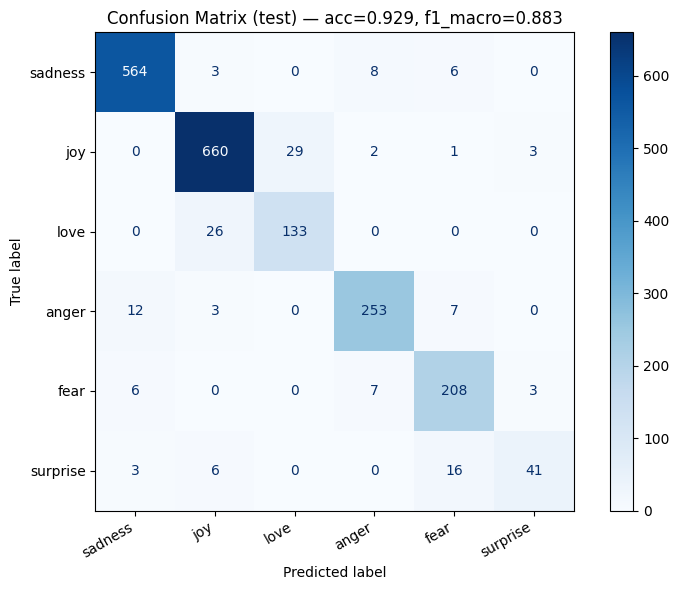

Saved confusion_matrix.png


In [19]:
# Confusion Matrix
cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix (test) — acc={test_acc:.3f}, f1_macro={test_f1:.3f}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion_matrix.png")

## 7. Примеры предсказаний и артефакт `sample_predictions.csv`

In [20]:
# Собираем таблицу предсказаний на всём test
test_texts = raw_dataset["test"]["text"]

predictions_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [id2label[t] for t in test_true],
    "pred_label": [id2label[p] for p in test_preds],
    "confidence": [float(test_probs[i, test_preds[i]]) for i in range(len(test_preds))],
})

predictions_df["correct"] = predictions_df["true_label"] == predictions_df["pred_label"]

# Сохраняем sample_predictions.csv (первые 50 + все ошибки)
errors = predictions_df[~predictions_df["correct"]]
correct_sample = predictions_df[predictions_df["correct"]].head(30)
sample_preds = pd.concat([correct_sample, errors], ignore_index=True).drop(columns=["correct"])

sample_preds.to_csv(
    os.path.join(ARTIFACTS_DIR, "sample_predictions.csv"),
    index=False,
)
print(f"Saved sample_predictions.csv ({len(sample_preds)} rows)")
print(f"Total errors on test: {len(errors)} / {len(predictions_df)}")
print()

# Показываем 10 примеров
display(sample_preds.head(10))

Saved sample_predictions.csv (171 rows)
Total errors on test: 141 / 2000



,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9991
1,im updating my blog because i feel shitty,sadness,sadness,0.9992
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9992
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9991
4,i was feeling a little vain when i did this one,sadness,sadness,0.9992
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.9975
6,i felt anger when at the end of a telephone call,anger,anger,0.9872
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitem...,joy,joy,0.8319
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9990
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as...,anger,anger,0.9980


## 8. Анализ ошибок

In [21]:
# Ошибки модели
errors_df = predictions_df[~predictions_df["correct"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False).reset_index(drop=True)

print(f"Всего ошибок на test: {len(errors_df)} из {len(predictions_df)}")
print(f"Accuracy: {test_acc:.4f}")
print()

if len(errors_df) > 0:
    print("Самые уверенные ошибки (модель ошиблась, но была уверена):")
    display(errors_df.head(10))
    
    print("\nРаспределение ошибок по true_label:")
    display(errors_df["true_label"].value_counts())
    
    print("\nРаспределение ошибок по pred_label:")
    display(errors_df["pred_label"].value_counts())
    
    print("\nЧастые пары true -> pred:")
    display(errors_df.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False).head(10))
else:
    print("Ошибок на тестовой выборке не найдено.")

Всего ошибок на test: 141 из 2000
Accuracy: 0.9295

Самые уверенные ошибки (модель ошиблась, но была уверена):


,text,true_label,pred_label,confidence,correct
0,whenever i put myself in others shoes and try to make the person happy,anger,joy,0.9990,False
1,i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to ...,fear,sadness,0.9984,False
2,i grabbed my dog and hugged her fiercly for the next hour or so until i began to feel a bit like myself again but i ...,fear,sadness,0.9979,False
3,i cannot even begin to express in words the depth of sorrow that i feel having not posted any of my ludicrous rants ...,surprise,sadness,0.9977,False
4,i just feel are ludicrous and wasting space or so trite they should have looked at the book first and come up with s...,surprise,sadness,0.9946,False
5,i actually was in a meeting last week where someone yelled at an older lady because her phone rang i felt terrible f...,anger,sadness,0.9939,False
6,i really dont like quinn because i feel like she will just end up hurting barney and i hated the lame ted robin stor...,anger,sadness,0.9868,False
7,i feel affirmed gracious sensuous and will have less self doubt when a href http generations,love,joy,0.9862,False
8,when i learnt that my best friend had failed the exams,anger,sadness,0.9857,False
9,ive come to feel about a supporting character in one of my all time favorite films giant,joy,love,0.9853,False



Распределение ошибок по true_label:


true_label
joy         35
love        26
surprise    25
anger       22
sadness     17
fear        16
Name: count, dtype: int64


Распределение ошибок по pred_label:


pred_label
joy         38
fear        30
love        29
sadness     21
anger       17
surprise     6
Name: count, dtype: int64


Частые пары true -> pred:


true_label  pred_label
joy         love          29
love        joy           26
surprise    fear          16
anger       sadness       12
sadness     anger          8
anger       fear           7
fear        anger          7
sadness     fear           6
fear        sadness        6
surprise    joy            6
dtype: int64

## 9. Итоги

1. **Датасет `emotion`** содержит 6 классов эмоций, что делает задачу нетривиальной.
2. **Токенизация** превращает текст в `input_ids` + `attention_mask` — стандартный формат входа BERT.
3. **Готовая pretrained модель** показала хорошие результаты, но цель — научиться делать fine-tuning самостоятельно.
4. **Fine-tuning `distilbert-base-uncased`** позволил достичь высокого качества на test.\n
5. **Confusion matrix** показывает, какие классы модель путает чаще всего.
6. **Анализ ошибок** помогает понять ограничения и направления для улучшения.